In [1]:
# Basis
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
import contextily as cx
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
# and from hydrolib-core
from hydrolib.core.dimr.models import DIMR, FMComponent
from hydrolib.core.dflowfm.inifield.models import IniFieldModel, DiskOnlyFileModel
from hydrolib.core.dflowfm.onedfield.models import OneDFieldModel
from hydrolib.core.dflowfm.structure.models import StructureModel
from hydrolib.core.dflowfm.crosssection.models import CrossLocModel, CrossDefModel
from hydrolib.core.dflowfm.ext.models import ExtModel
from hydrolib.core.dflowfm.mdu.models import FMModel
from hydrolib.core.dflowfm.friction.models import FrictionModel
from hydrolib.core.dflowfm.obs.models import ObservationPointModel
from hydrolib.core.dflowfm.storagenode.models import StorageNodeModel

In [3]:
from hydrolib.dhydamo.core.hydamo import HyDAMO
from hydrolib.dhydamo.converters.df2hydrolibmodel import Df2HydrolibModel
from hydrolib.dhydamo.geometry import mesh
from hydrolib.dhydamo.core.drr import DRRModel
from hydrolib.dhydamo.core.drtc import DRTCModel
from hydrolib.dhydamo.io.dimrwriter import DIMRWriter
from hydrolib.dhydamo.io.drrwriter import DRRWriter
from hydrolib.dhydamo.geometry.viz import plot_network
from meshkernel.py_structures import DeleteMeshOption

In [4]:
%load_ext autoreload
%autoreload 2

Define in- and output paths

In [ ]:
# selectie_gebied = 0 # Oude IJssel
selectie_gebied = 1 # West
# selectie_gebied = 2 # Centraal
# selectie_gebied = 3 # Oost

scenario = "scenario_test"

start_date = "2010-4-1"
end_date = "2010-9-30"

# path to the package containing the dummy-data
dir_data = Path("..\\..\\WRIJ_RR_Unpaved_methode_02_input\\rr_input_area_scenario")

In [ ]:
# Hier begint de functie
# def genereer_rr_model(selectie_gebied, scenario, start_date, end_date):

In [ ]:
dir_gebied = Path(dir_data, f"gebied_{selectie_gebied}")

gebied = gpd.read_file(dir_gebied / f"gebied.gpkg", layer=f"gebied")
watergang = gpd.read_file(dir_gebied / f"watergang.gpkg", layer=f"watergang")
laterale_knoop = gpd.read_file(dir_gebied / f"laterale_knoop.gpkg", layer=f"laterale_knoop")
afwateringseenheden = gpd.read_file(dir_gebied / f"afwateringseenheden.gpkg", layer=f"afwateringseenheden")

## Rainfall runoff model

RR has not changed yet compared to delft3dfmpy. Initialize a model:

In [8]:
drrmodel = DRRModel()

In [9]:
df_unpaved_zomer = pd.read_csv(dir_gebied / scenario / f"df_unpaved_zomer.csv")
df_unpaved_winter = pd.read_csv(dir_gebied / scenario / f"df_unpaved_winter.csv")
df_ernst_zomer = pd.read_csv(dir_gebied / scenario / f"df_ernst_zomer.csv")
df_ernst_winter = pd.read_csv(dir_gebied / scenario / f"df_ernst_winter.csv")

### Unpaved nodes

Unpaved_from_input has now an optional argument containing the greenhouse areas: if a catchment intersects them its area (the most ocurring class) is corrected for the greenhouse area. 

In [10]:
for unpaved_dict in df_unpaved_zomer.set_index("code").to_dict("records"):
    drrmodel.unpaved.add_unpaved(**unpaved_dict)

for ernst_dict in df_ernst_zomer.set_index("code").to_dict("records"):
    drrmodel.unpaved.add_ernst_def(**ernst_dict)

### Open water

As opposed to Sobek, in D-Hydro open water is merely an interface for precpitation and evaporation. No management and water levels are included.

In [ ]:
# selecteer gebied extent
path_extent_project_area = dir_gebied / "gebied.gpkg"
hydamo = HyDAMO(extent_file=path_extent_project_area)

In [12]:
path_watergangen = Path(dir_gebied, "watergang.gpkg")
hydamo.branches.read_gpkg_layer(path_watergangen, layer_name="watergang", index_col="code")

Index column 'code' contains duplicates (['OIJ20.005']). Adding a suffix to make it unique.


In [13]:
# read catchments
path_afwateringseenheden = Path(dir_gebied, "afwateringseenheden.gpkg")
hydamo.catchments.read_gpkg_layer(path_afwateringseenheden, layer_name="afwateringseenheden", index_col="code", check_geotype=False)

In [15]:
laterals_gdf = gpd.GeoDataFrame(df_unpaved_zomer, geometry=gpd.points_from_xy(df_unpaved_zomer.px-10, df_unpaved_zomer.py-10), crs=28992)
laterals_gdf["rr_node"] = laterals_gdf["code"]
laterals_gdf["code"] = laterals_gdf["boundary_node"]
laterals_gdf["globalid"] = laterals_gdf["code"]
laterals_gdf = laterals_gdf[["code", "rr_node", "globalid", "geometry"]].set_index("code")
laterals_gdf.to_file(dir_data / "laterale_knoop.gpkg", layer="laterale_knoop", driver="GPKG")

In [16]:
# read laterals
hydamo.laterals.read_gpkg_layer(dir_data / "laterale_knoop.gpkg", layer_name="laterale_knoop")
hydamo.laterals.snap_to_branch(hydamo.branches, snap_method="overal", maxdist=5000)
hydamo.catchments['boundary_node'] = hydamo.catchments['lateraleknoopid'].copy()

### RR boundaries

They are different for the (paved) case with and without overflows. Overflows and greenhouse laterals are optional, but should be provided if they have been used above. 

In [17]:
drrmodel.external_forcings.io.boundary_from_input(
    hydamo.laterals, 
    hydamo.catchments, 
    drrmodel, 
)

### External forcings

Three types of external forcing need to be provided:<br>
- Seepage/drainage
- Precipitation
- Evaporation

All are assumed to be spatially variable and thus need to pe provided as rasters per time step. Only the locations of the folders containing the rasters need to be provided; the time step is then derived from the file names.

Precipitation and evaporation are assumed to be in mm/d. As for evaporation only one meteostation is used, the meteo_areas are dissolved. For seepage, as the use of Metaswap-rasters is allowed, the unit is assumed to m3/grid cell/timestep.

Rastertypes can be any type that is recognized by rasterio (in any case Geotiff and ArcASCII rasters). If the file extension is 'IDF', as is the case in Modflow output, the raster is read using the 'imod'-package.

IMPORTANT: time steps are extracted from the file names. Therefore, the names should cohere to some conditions:
The filename should consist of at least two parts, separated by underscores. The second part needs to contain time information, which should be formatted as YYYYMMDDHHMMSS (SS may be omitted). Or, for daily data YYYYMMDD.

For example: 'precip_20200605151500.tif'

Extracting meteo-data from rasters can be time consuming. If precip_file and evap_file are specified, meteo-files are copied from an existing location.

In [18]:
seepage_file = str(dir_gebied / "seepage.csv")
precip_file = str(dir_gebied / "meteo" / "METEO_NEERSLAG.BUI")
evap_file = str(dir_gebied / "meteo" / "METEO_VERDAMPING.EVP")

seepage_df = pd.read_csv(seepage_file, index_col=0, parse_dates=True)
[drrmodel.external_forcings.add_seepage(*sep) for sep in seepage_df.items()]
drrmodel.external_forcings.io.precip_from_input(hydamo.catchments, precip_folder=None, precip_file=precip_file)
drrmodel.external_forcings.io.evap_from_input(hydamo.catchments, evap_folder=None, evap_file=evap_file)

Add the main parameters:

In [ ]:
drrmodel.d3b_parameters["Timestepsize"] = 300
drrmodel.d3b_parameters["StartTime"] = "'" + pd.to_datetime(start_date).strftime('%Y/%m/%d;%H:%M:%S') + "'"  # should be equal to refdate for D-HYDRO
drrmodel.d3b_parameters["EndTime"] = "'" + pd.to_datetime(end_date).strftime('%Y/%m/%d;%H:%M:%S') + "'"
drrmodel.d3b_parameters["RestartIn"] = 0
drrmodel.d3b_parameters["RestartOut"] = 1
drrmodel.d3b_parameters["RestartFileNamePrefix"] = "Test"
drrmodel.d3b_parameters["UnsaturatedZone"] = 1
drrmodel.d3b_parameters["UnpavedPercolationLikeSobek213"] = -1
drrmodel.d3b_parameters["VolumeCheckFactorToCF"] = 100000

Laterals are different for the case with and without RR. There can be three options:
1) laterals from the RR model (RR=True). There will be real-time coupling where RR and FM are calculated in parallel. Note that, again, the overflows are needed because there are extra boundaries. If there are no overflows, it does not have to be provided.
2) timeseries: lateral_discharges can be a dataframe with the code of the lateral as column headers and timesteps as index
3) constant: lateral_discharges can be a pandas Series with the code of the lateral as the index. This is the case in the example when RR=False.

In [40]:
hydamo.external_forcings.convert.laterals(
    hydamo.laterals,
    # overflows=hydamo.overflows,
    # greenhouse_laterals=hydamo.greenhouse_laterals,
    lateral_discharges=None,
    rr_boundaries=drrmodel.external_forcings.boundary_nodes
)

## Writing the model

In D-Hydro the 1D timestep (dt user) should be at least equal to than the smallest timestep of RR and RTC, otherwise water balance problems may occur.
The following code sets 'dtuser' equal to the smallest time step.

In [ ]:
# overwrite output-path to write the models
output_path = dir_gebied / scenario / "rr_model"

if not output_path.exists():
    output_path.mkdir(parents=True)

rr_writer = DRRWriter(drrmodel, output_dir=output_path)
rr_writer.write_all()

In [1]:
# KOPIEREN VAN DIMR_CONFIG EN RUN.BAT NAAR OUTPUT_PATH

A run.bat that will run DIMR is written by the following command. Adjust this with your local D-Hydro Suite version.

### Plot the RR model

In [ ]:
def node_geometry(dict):
    # Function to put the node geometries in geodataframes
    from shapely.geometry import Point, LineString

    geoms = []
    links = []
    for i in dict.items():
        if "ar" in i[1]:
            if np.sum([float(s) for s in i[1]["ar"].split(" ")]) > 0:
                geoms.append(Point((float(i[1]["px"]), float(i[1]["py"]))))
                links.append(
                    LineString(
                        (
                            Point(float(i[1]["px"]), float(i[1]["py"])),
                            Point(
                                float(drrmodel.external_forcings.boundary_nodes[i[1]["boundary_node"]]["px"]),
                                float(drrmodel.external_forcings.boundary_nodes[i[1]["boundary_node"]]["py"]),
                            ),
                        )
                    )
                )
        else:
            geoms.append(Point((float(i[1]["px"]), float(i[1]["py"]))))
    return ((gpd.GeoDataFrame(geoms, columns=["geometry"])), gpd.GeoDataFrame(links, columns=["geometry"]))

C:\Users\NLHARN\AppData\Local\Temp\ipykernel_36852\3984651688.py:18: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  node_geometry(drrmodel.paved.pav_nodes)[0].plot(ax=ax, markersize=20, marker="s", color="red", label="Paved")
C:\Users\NLHARN\AppData\Local\Temp\ipykernel_36852\3984651688.py:19: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  node_geometry(drrmodel.paved.pav_nodes)[1].plot(ax=ax, color="black", linewidth=0.5)
C:\Users\NLHARN\AppData\Local\Temp\ipykernel_36852\3984651688.py:20: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  node_geometry(drrmodel.greenhouse.gh_nodes)[0].plot(ax=ax, markersize=15, color="yellow", label="Greenhouse")
C:\Users\NLHARN\AppData\Local\Temp\ipykernel_36852\3984651688.py:21: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  node_geometry(drrmodel.greenhou

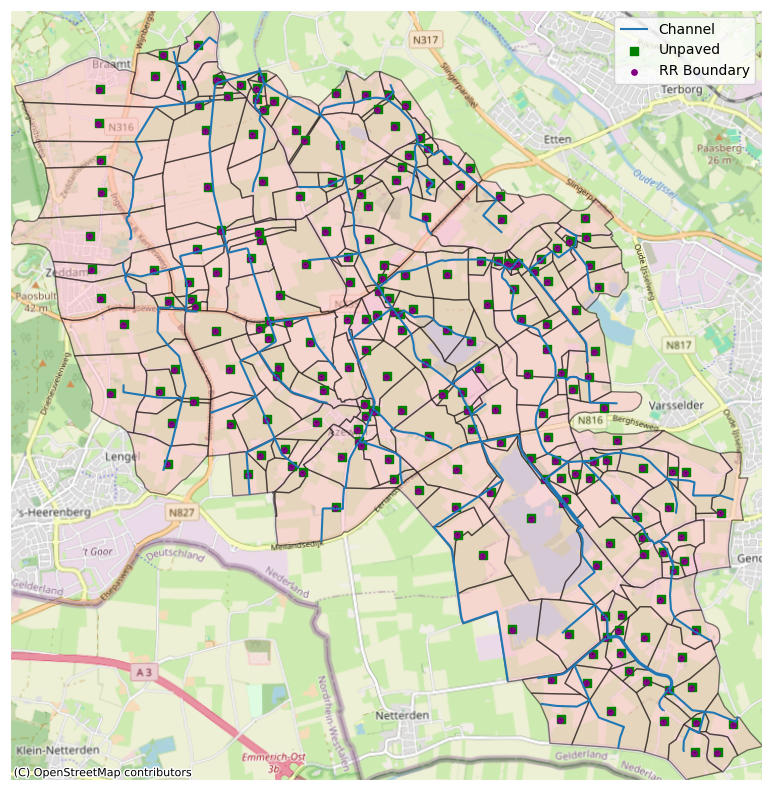

In [ ]:
plt.rcParams['axes.edgecolor'] = 'w'
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(8, 8))

ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
xmin,ymin,xmax,ymax=hydamo.clipgeo.bounds
ax.set_xlim(round(xmin), round(xmax))
ax.set_ylim(round(ymin), round(ymax))

hydamo.catchments.geometry.plot(ax=ax, label="Catchments", edgecolor="black", facecolor="pink", alpha=0.5)
hydamo.branches.geometry.plot(ax=ax, label="Channel")
node_geometry(drrmodel.unpaved.unp_nodes)[0].plot(
    ax=ax, markersize=30, marker="s", color="green", label="Unpaved"
)
node_geometry(drrmodel.unpaved.unp_nodes)[1].plot(ax=ax, color="black", linewidth=0.5)
node_geometry(drrmodel.paved.pav_nodes)[0].plot(ax=ax, markersize=20, marker="s", color="red", label="Paved")
node_geometry(drrmodel.paved.pav_nodes)[1].plot(ax=ax, color="black", linewidth=0.5)
node_geometry(drrmodel.greenhouse.gh_nodes)[0].plot(ax=ax, markersize=15, color="yellow", label="Greenhouse")
node_geometry(drrmodel.greenhouse.gh_nodes)[1].plot(ax=ax, color="black", linewidth=0.5)
node_geometry(drrmodel.openwater.ow_nodes)[0].plot(ax=ax, markersize=10, color="blue", label="Openwater")
node_geometry(drrmodel.openwater.ow_nodes)[1].plot(ax=ax, color="black", linewidth=0.5, label="RR-link")
node_geometry(drrmodel.external_forcings.boundary_nodes)[0].plot(
    ax=ax, markersize=15, color="purple", label="RR Boundary"
)

# manually add handles for polygon plot
handles, labels = ax.get_legend_handles_labels()
poly = mpatches.Patch(facecolor="pink", edgecolor="black", alpha=0.5)    
ax.legend(handles=handles.append(poly), labels=labels.append("Catchments"))
cx.add_basemap(ax, crs=28992, source=cx.providers.OpenStreetMap.Mapnik)
fig.tight_layout()